In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.shape

(8807, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [7]:
df.duplicated().sum()

np.int64(0)

1. The dataset contains Netflix movies and TV shows.
2. It includes information about titles, countries, ratings and release years.
3. The dataset contains content from multiple countries.
4. Movies and TV Shows are the two main categories.
5. The dataset helps analyze Netflix content trends.

In [8]:
df.drop("show_id",axis=1,inplace=True)

In [9]:
df["director"].fillna("Unknown",inplace=True)

df["cast"].fillna("Unknown",inplace=True)

df["country"].fillna("Unknown",inplace=True)

df["rating"].fillna("Unknown",inplace=True)

/tmp/ipykernel_993/247495999.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["director"].fillna("Unknown",inplace=True)
/tmp/ipykernel_993/247495999.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

In [10]:
df.dropna(subset=["date_added"],inplace=True)

In [12]:
# Remove extra spaces
df["date_added"] = df["date_added"].str.strip()

# Convert to datetime
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

In [13]:
df["date_added"].head()

,date_added
0,2021-09-25
1,2021-09-24
2,2021-09-24
3,2021-09-24
4,2021-09-24


In [14]:
df.drop_duplicates(inplace=True)

Exploratory Data Analysis

Q1: How many Movies and TV Shows are available?

In [15]:
df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2666


Q2: Which countries produce the most content?

In [16]:
df["country"].value_counts().head(10)

,count
country,
United States,2812
India,972
Unknown,830
United Kingdom,418
Japan,244
South Korea,199
Canada,181
Spain,145
France,124


Q3: What are the most common ratings?

In [17]:
df["rating"].value_counts().head(10)

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


Q4: How has Netflix content changed over years?

In [18]:
df["release_year"].value_counts().sort_index()

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1032
2018,1146
2019,1030


Q5: What is average movie duration?

In [19]:
movies=df[df["type"]=="Movie"]

movies["duration_min"]=(
movies["duration"]
.str.replace(" min","")
.astype(float)
)

movies["duration_min"].describe()

/tmp/ipykernel_993/2559194466.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies["duration_min"]=(


,duration_min
count,6128.000000
mean,99.577187
std,28.290593
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


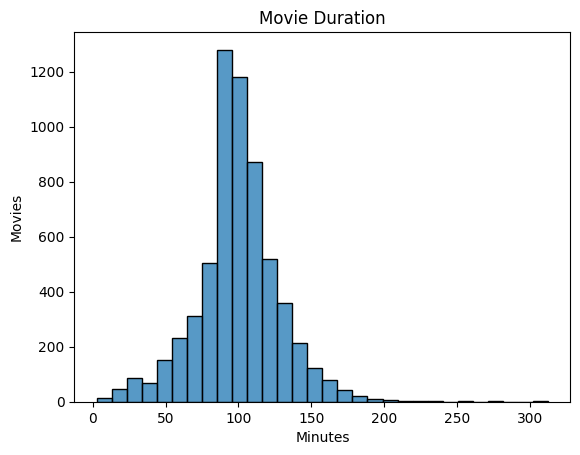

In [22]:
sns.histplot(movies["duration_min"],bins=30)

plt.title("Movie Duration")

plt.xlabel("Minutes")

plt.ylabel("Movies")

plt.show()

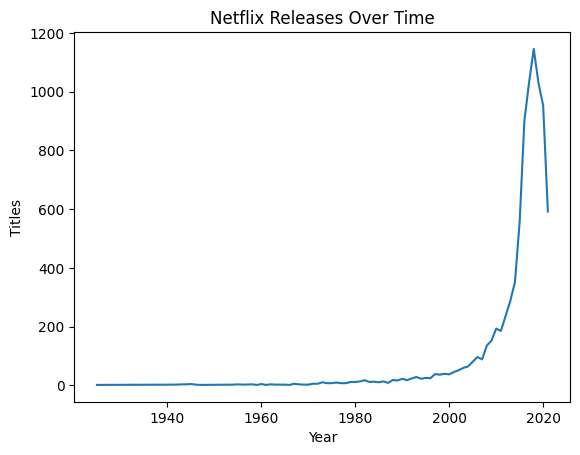

In [21]:
year=df["release_year"].value_counts().sort_index()

plt.plot(year.index,year.values)

plt.title("Netflix Releases Over Time")

plt.xlabel("Year")
plt.ylabel("Titles")

plt.show()

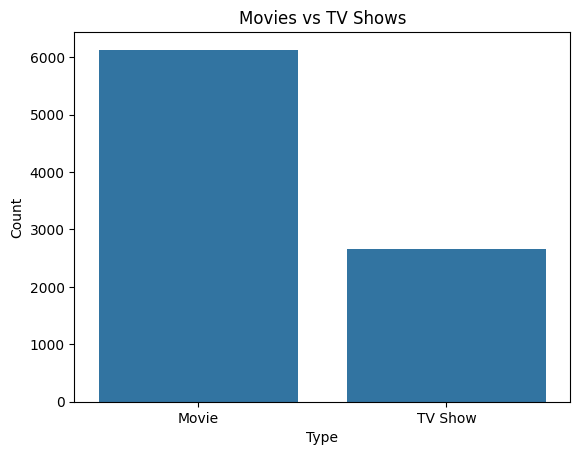

In [20]:
sns.countplot(data=df,x="type")

plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

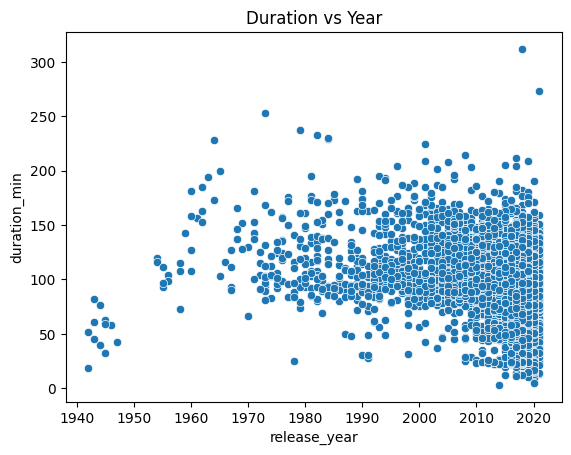

In [23]:
sns.scatterplot(
data=movies,
x="release_year",
y="duration_min"
)

plt.title("Duration vs Year")

plt.show()

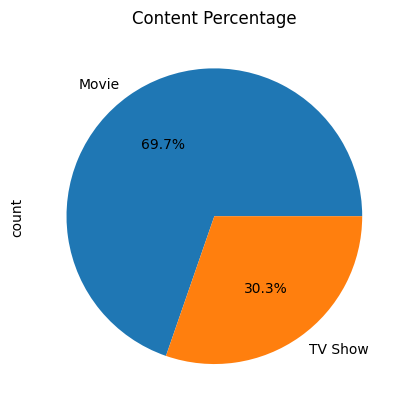

In [24]:
df["type"].value_counts().plot.pie(
autopct="%1.1f%%"
)

plt.title("Content Percentage")

plt.show()

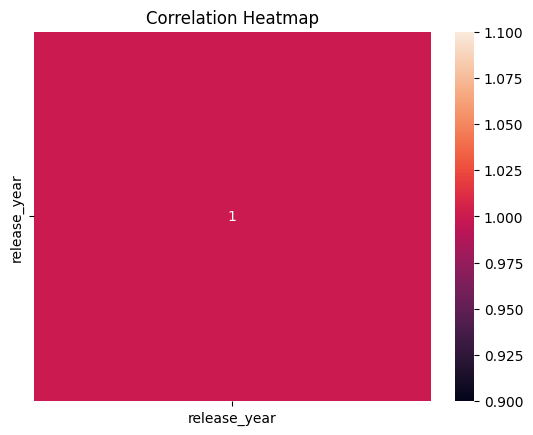

In [25]:
sns.heatmap(
df.select_dtypes("number").corr(),
annot=True
)

plt.title("Correlation Heatmap")

plt.show()

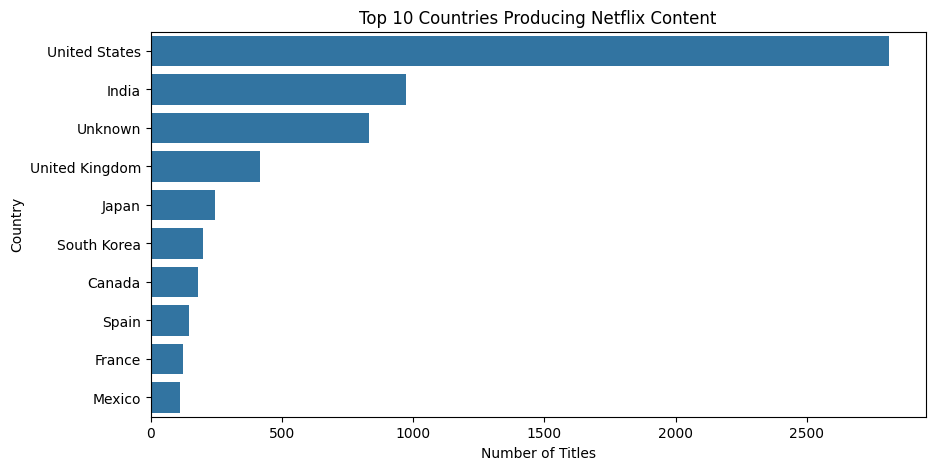

In [26]:
plt.figure(figsize=(10,5))

country_count = (
    df["country"]
    .value_counts()
    .head(10)
)

sns.barplot(
    x=country_count.values,
    y=country_count.index
)

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

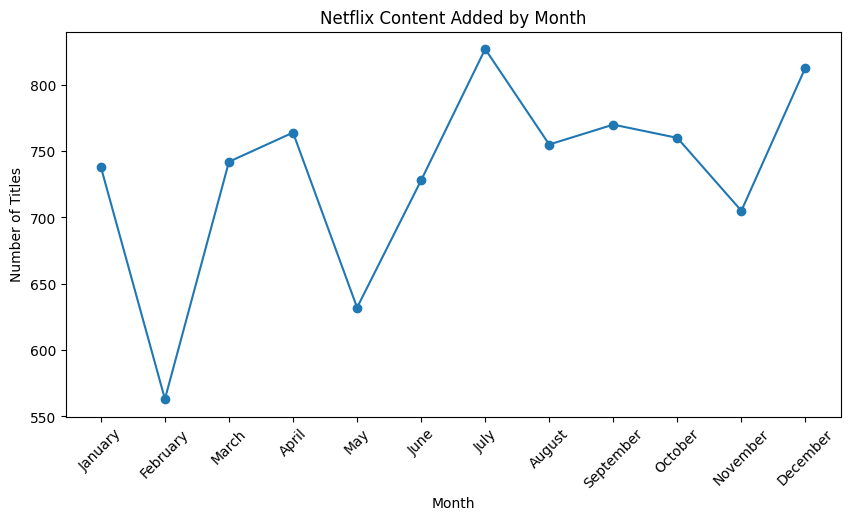

In [27]:
df["month_added"] = df["date_added"].dt.month_name()

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly = (
    df["month_added"]
    .value_counts()
    .reindex(month_order)
)


plt.figure(figsize=(10,5))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o"
)

plt.title("Netflix Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

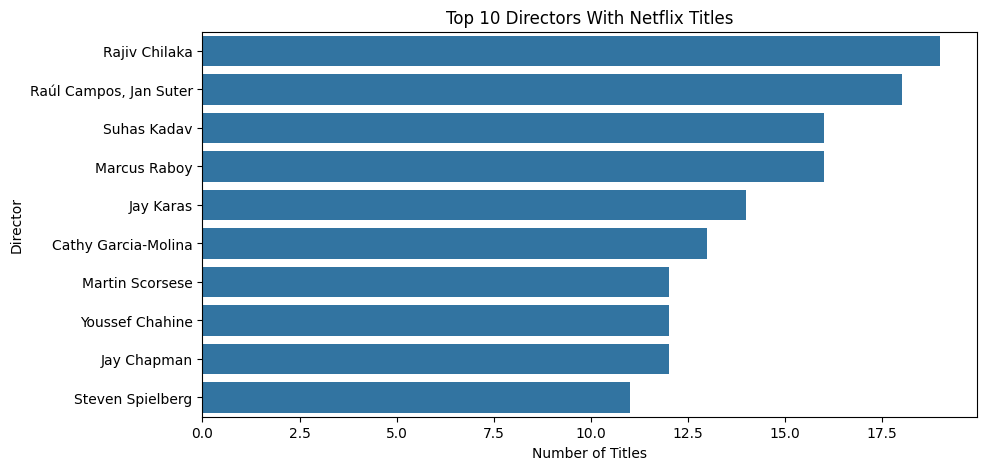

In [28]:
directors = (
    df[df["director"]!="Unknown"]
    ["director"]
    .value_counts()
    .head(10)
)


plt.figure(figsize=(10,5))

sns.barplot(
    x=directors.values,
    y=directors.index
)

plt.title("Top 10 Directors With Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()

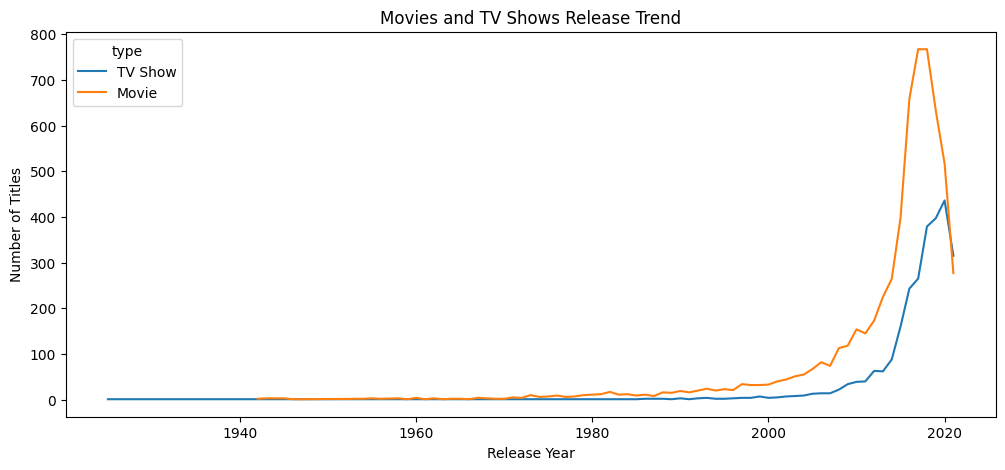

In [29]:
trend = (
    df.groupby(
        ["release_year","type"]
    )
    .size()
    .reset_index(name="count")
)


plt.figure(figsize=(12,5))

sns.lineplot(
    data=trend,
    x="release_year",
    y="count",
    hue="type"
)


plt.title("Movies and TV Shows Release Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

***Insights***

1. Movies are the largest content category on Netflix.
2. Netflix content increased rapidly after 2015.
3. Most movies have a duration between 80-120 minutes.
4. USA is one of the biggest content producers.
5. Netflix contains a large amount of mature-rated content.